### __Examples: Multiple linear regression – advanced regression analysis 1__

| Action            | Shortcut        |
| ----------------- | --------------- |
| Code → Markdown   | `Esc`, `M`      |
| Markdown → Code   | `Esc`, `Y`      |
| Run cell          | `Shift + Enter` |
| Insert cell above | `A`             |
| Insert cell below | `B`             |
| Delete cell       | `D`, `D`        |


In this notebook, we will delve deeper into multiple linear regression. We employ statistical tests and diagnostics from the Statsmodels library to assess model quality comprehensively. Using the mtcars dataset, we explore linearity and multicollinearity, as well as fit a model, enriching our regression analysis toolkit.

## __Learning objectives__

By the end of this notebook, you should be able to:
* Understand the importance of statistical diagnostics in regression analysis.
* Perform exploratory data analysis on a regression dataset.
* Check for linearity between predictor and response variables.
* Identify and address multicollinearity issues in the dataset.
* Fit a multiple linear regression model using Statsmodels and interpret its summary

### __Introduction__
Previously, we explored the use of `sklearn` and multiple predictors to fit a regression model. When it comes to regression, there aren't many metrics and tools available in `sklearn` that allow us to assess the quality of our fitted models. Moreover, we require further techniques that will enable us to validate the characteristics of our initial data prior to conducting any modelling.

In order to more accurately assess a regression model's quality, we go over a thorough set of methods that centre on statistical testing. This notebook is an adaptation of [this Medium article](https://towardsdatascience.com/how-do-you-check-the-quality-of-your-regression-model-in-python-fa61759ff685).

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
from styleplot import style_plot

In [3]:
cars = pd.read_csv("mtcars.csv")

In [4]:
cars.head(4)

,mpg,cyl,disp,hp,drat,wt,qsec,vs,am,gear,carb
0,21.0,6,160.0,110,3.90,2.620,16.46,0,1,4,4
1,21.0,6,160.0,110,3.90,2.875,17.02,0,1,4,4
2,22.8,4,108.0,93,3.85,2.320,18.61,1,1,4,1
3,21.4,6,258.0,110,3.08,3.215,19.44,1,0,3,1


In [5]:
cars.describe().T

,count,mean,std,min,25%,50%,75%,max
mpg,32.0,20.090625,6.026948,10.400,15.42500,19.200,22.80,33.900
cyl,32.0,6.187500,1.785922,4.000,4.00000,6.000,8.00,8.000
disp,32.0,230.721875,123.938694,71.100,120.82500,196.300,326.00,472.000
hp,32.0,146.687500,68.562868,52.000,96.50000,123.000,180.00,335.000
drat,32.0,3.596563,0.534679,2.760,3.08000,3.695,3.92,4.930
wt,32.0,3.217250,0.978457,1.513,2.58125,3.325,3.61,5.424
qsec,32.0,17.848750,1.786943,14.500,16.89250,17.710,18.90,22.900
vs,32.0,0.437500,0.504016,0.000,0.00000,0.000,1.00,1.000
am,32.0,0.406250,0.498991,0.000,0.00000,0.000,1.00,1.000
gear,32.0,3.687500,0.737804,3.000,3.00000,4.000,4.00,5.000


It appears both `vs` and `am` are categorical variables. From the dataset description [available here](https://rpubs.com/neros/61800), `vs` takes on a value of 0 or 1 depending on whether the engine layout is a *V* or *straight*. `am` also takes on a value of 0 or 1 depending on whether the transmission is *automatic* or *manual*.

Note that these don't need to be one-hot encoded because they are binary categorical variables (only two categories each), and they already make use of zeros and ones.

### __Checking for linearity__

The first step in our analysis involves assessing the mathematical relationship between each predictor variable and the response variable. Linearity is a crucial aspect that we need to evaluate. A linear relationship implies that the change in the response variable *Y*, resulting from a one-unit change in the predictor $X_j$, remains consistent across different values of $X_j$.

If we attempt to fit a regression model to a dataset that exhibits non-linear patterns, the model may inadequately capture the underlying relationships within the data, leading to inaccuracies in predictions. To assess linearity, we often create scatter plots for each predictor against the response variable. This visual examination helps us identify any apparent linear trends in the data.

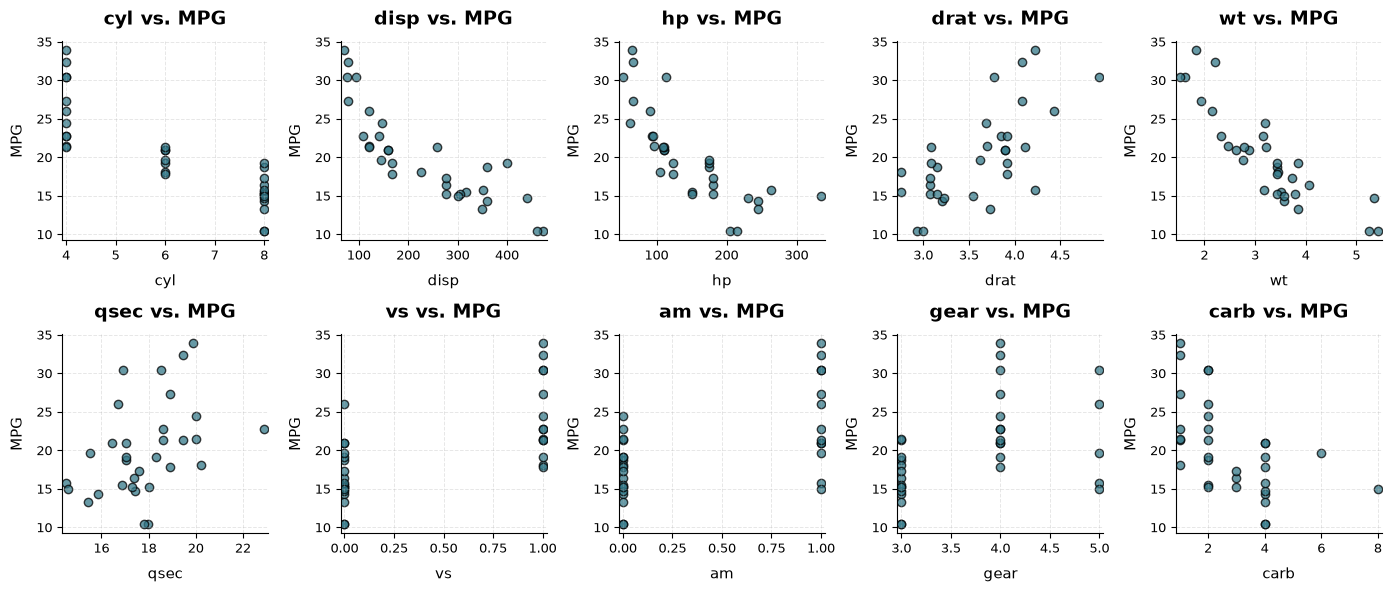

In [26]:
fig, axs = plt.subplots(2, 5, figsize=(14, 6))

axs = axs.ravel()

predictors = cars.drop(columns=["mpg"]).columns

for index, column in enumerate(predictors):
    axs[index].scatter(
        cars[column],
        cars["mpg"],
        color= "#347989",
        alpha = 0.75,
        edgecolor="k"
    )

    style_plot(
        axs[index],
        title=f"{column} vs. MPG",
        xlabel=column,
        ylabel="MPG"
    )

plt.tight_layout(pad=1)
plt.show()

__Note:__
> __ravel()__ turns your subplot grid into a single row of axes, making iteration with a for loop much easier.

It appears that a significant amount of our variables have an approximately linear relationship. Here, a trend between each of `disp, hp, drat, wt`, `qsec`, and `mpg` seems to exist.

Based on these findings, it appears that there is enough linearity present to apply a linear regression model. Let us proceed.

We'll make a duplicate of the dataset to experiment with and process it with `statsmodels.OLS()`, the least squares regression module in the `statsmodels` library. We'll use this module to perform our regression.

In [7]:
df = cars.copy()

### __Checking for multicollinearity__

Multicollinearity refers to the presence of a strong correlation among two or more of the predictor variables in the dataset. The presence of any correlation among predictors is detrimental to model quality for two reasons:

1.  It tends to increase the standard error of the coefficients estimates, making them less precise and leading to wider confidence intervals.

2. It becomes difficult to estimate the effect of any one predictor variable on the response variable because multicollinearity makes the coefficients sensitive to small changes in the model or the data, which can lead to unstable coefficient estimates.

We will test for multicollinearity by creating a correlation matrix and using Variance Inflation Factor (VIF).

<br>1. Correlation matrix — quick screening for highly correlated predictors. It answers "Which pairs of predictors are strongly related?"
<br>2. Variance Inflation Factor (VIF) — the standard diagnostic for multicollinearity in regression. "How much does the overall predictor set inflate the uncertainty of each regression coefficient?"

Since `mpg` is your target, we should exclude it when checking predictor collinearity.

### 1. __Pearson correlation matrix__

In [8]:
# Exclude the target variable
X = df.drop(columns="mpg")

# Correlation matrix
correlation = X.corr()

# Display correlations
correlation

,cyl,disp,hp,drat,wt,qsec,vs,am,gear,carb
cyl,1.000000,0.902033,0.832447,-0.699938,0.782496,-0.591242,-0.810812,-0.522607,-0.492687,0.526988
disp,0.902033,1.000000,0.790949,-0.710214,0.887980,-0.433698,-0.710416,-0.591227,-0.555569,0.394977
hp,0.832447,0.790949,1.000000,-0.448759,0.658748,-0.708223,-0.723097,-0.243204,-0.125704,0.749812
drat,-0.699938,-0.710214,-0.448759,1.000000,-0.712441,0.091205,0.440278,0.712711,0.699610,-0.090790
wt,0.782496,0.887980,0.658748,-0.712441,1.000000,-0.174716,-0.554916,-0.692495,-0.583287,0.427606
qsec,-0.591242,-0.433698,-0.708223,0.091205,-0.174716,1.000000,0.744535,-0.229861,-0.212682,-0.656249
vs,-0.810812,-0.710416,-0.723097,0.440278,-0.554916,0.744535,1.000000,0.168345,0.206023,-0.569607
am,-0.522607,-0.591227,-0.243204,0.712711,-0.692495,-0.229861,0.168345,1.000000,0.794059,0.057534
gear,-0.492687,-0.555569,-0.125704,0.699610,-0.583287,-0.212682,0.206023,0.794059,1.000000,0.274073
carb,0.526988,0.394977,0.749812,-0.090790,0.427606,-0.656249,-0.569607,0.057534,0.274073,1.000000


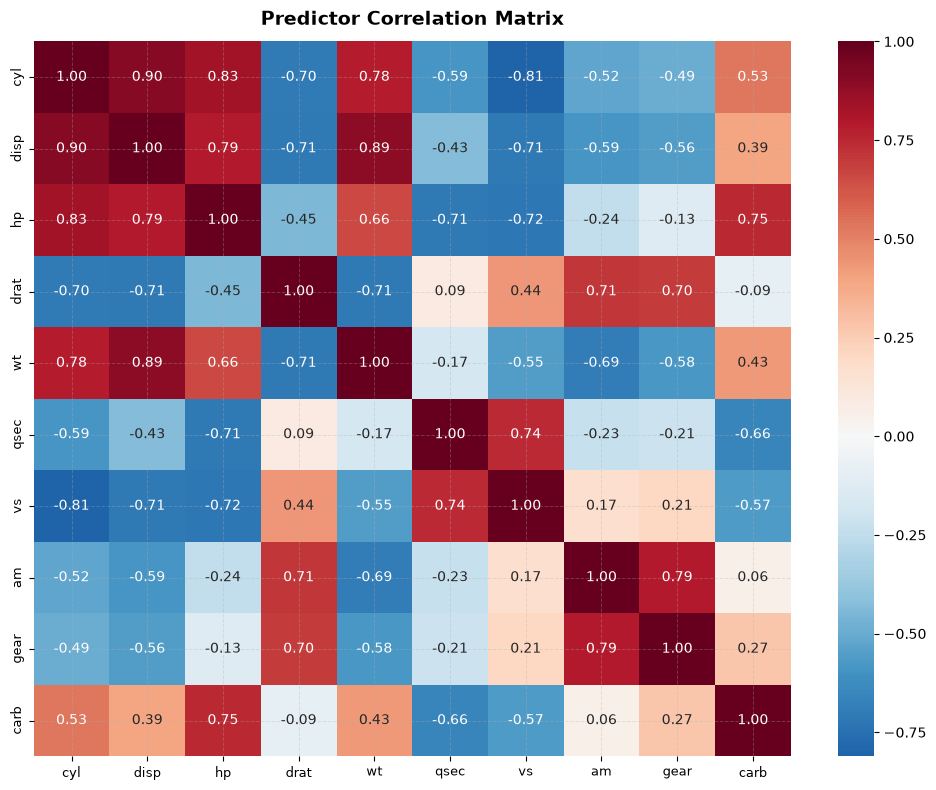

In [9]:
fig, ax = plt.subplots(figsize=(10, 8))

sns.heatmap(
    X.corr(),
    annot=True,
    fmt=".2f",
    cmap="RdBu_r",
    center=0,
    ax=ax
)

style_plot(
    ax,
    title="Predictor Correlation Matrix"
)

plt.tight_layout()
plt.show()

### 2. __Variance Inflation Factor__

In [10]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

In [11]:
# . VIF
vif = pd.DataFrame({
    "Feature": X.columns,
    "VIF": [
        variance_inflation_factor(X.values, i)
        for i in range(X.shape[1])
    ]
}).sort_values("VIF", ascending=False)

vif

,Feature,VIF
5,qsec,317.534376
4,wt,182.948049
3,drat,132.214353
8,gear,119.804879
0,cyl,112.629828
1,disp,98.930791
2,hp,56.047781
9,carb,32.213836
6,vs,8.752581
7,am,7.412020


### __How to interpret VIF__

|      VIF | Interpretation            |
| -------: | ------------------------- |
|      `1` | No collinearity           |
|  `1 – 5` | Generally acceptable      |
| `5 – 10` | Potential concern         |
|   `> 10` | Serious multicollinearity |


__Insight:__

> The multiple regression model exhibits substantial multicollinearity, with all predictors having VIF values above approximately 7 and eight predictors exceeding 10. This suggests that several vehicle characteristics provide overlapping information, which can inflate coefficient uncertainty and make individual coefficient interpretation unreliable.

One important point: __VIF__ measures multicollinearity among the predictors, not whether the model predicts MPG well. So your next comparison should be whether removing/reducing the collinear variables actually improves test-set performance.

### __Fitting the model using statsmodels.OLS__

As previously stated, `sklearn` has limited metrics and tools for evaluating the suitability of the regression models we fit. Thus, to broaden our scope, we import the `statsmodels` library, which contains a diverse range of statistical methods.

In [12]:
import statsmodels.api as sm
import statsmodels.stats.api as sms

### __Generating the regression string__

Those who are familiar with the R language will know that fitting a machine learning model often involves specifying the relationship between variables using a formula interface. In this interface, a string of the form:

`y ~ X`

is commonly used, where:
- *y* represents the response variable.
- $X$ represents one or more predictor variables.

The string is read as "Regress *y* on $X$", indicating that we want to model the relationship between the response variable *y* and the predictor variable(s) $X$.

Similarly, in Python's `statsmodels` library, the formula interface is used for specifying regression models. We need to generate an appropriate string following this pattern to specify the model when fitting a regression model using the formula interface. For example, *y* ~ $X_1$ + $X_2$ represents a model where *y* is regressed on predictor variables $X_1$ and $X_2$.

In [13]:
X = df.drop(columns="mpg")
y = df["mpg"]

In [14]:
print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (32, 10)
y shape: (32,)


#### __Add the intercept__

This is one of the biggest differences between scikit-learn and statsmodels.

In [15]:
X = sm.add_constant(X)

In [16]:
model = sm.OLS(y, X)
ols = model.fit()

print(ols.summary())

                            OLS Regression Results                            
Dep. Variable:                    mpg   R-squared:                       0.869
Model:                            OLS   Adj. R-squared:                  0.807
Method:                 Least Squares   F-statistic:                     13.93
Date:                Mon, 10 Aug 2026   Prob (F-statistic):           3.79e-07
Time:                        09:48:05   Log-Likelihood:                -69.855
No. Observations:                  32   AIC:                             161.7
Df Residuals:                      21   BIC:                             177.8
Df Model:                          10                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         12.3034     18.718      0.657      0.5

1. __The overall model is statistically significant__

The model has:

- R² = 0.869
- Adjusted R² = 0.807
- F-statistic = 13.93
- F-test p-value = 3.79 × 10⁻⁷

So the model explains about 86.9% of the variation in MPG in this sample.

The extremely small F-test p-value means the predictors are jointly significant: the model as a whole provides substantial explanatory power compared with an intercept-only model.

2. wt is the strongest individual candidate

Your wt coefficient is:

coef = -3.7153
p-value = 0.063

__Summary:__
> The MLR model explains a large proportion of MPG variation (R² = 0.869) and is highly significant overall (F-test p < 0.001). However, none of the individual predictors are statistically significant at the 5% level, with wt coming closest (p = 0.063). This apparent contradiction is consistent with the severe multicollinearity identified through the VIF analysis and large condition number. The relatively small sample size (32 observations) and 10 predictors also make the full model susceptible to coefficient instability and overfitting.


### __Checking for homoscedasticity__

The next check will be to see if the variance of the residuals remains constant as the fitted values grow.

### __Fitted vs. residuals__

We can assess the presence of homoscedasticity or heteroscedasticity by plotting the residuals against the fitted values (for example, `mpg`). In the case of homoscedasticity, the scatterplot should exhibit a random and uniform spread of points, indicating that the variance of the residuals remains constant across all levels of the predictor variable(s). Conversely, heteroscedasticity is evident when the spread of the residuals systematically changes as the fitted values increase or decrease, potentially resembling a cone shape.

### __What this checks__
- **Homoscedasticity:** residuals are randomly scattered around zero with roughly constant spread.
- **Heteroscedasticity:** residuals form a funnel/cone shape or their spread changes as fitted values increase.
- __Curved pattern:__ may indicate that the linear model is missing a nonlinear relationship.

Furthermore, examining the residuals plot can help identify outliers, which are data points that deviate significantly from the overall pattern of the residuals. Outliers should be carefully investigated as they can distort model assumptions and influence the estimation of parameters.

In [17]:
predicted_values = ols.fittedvalues   
residuals = ols.resid   

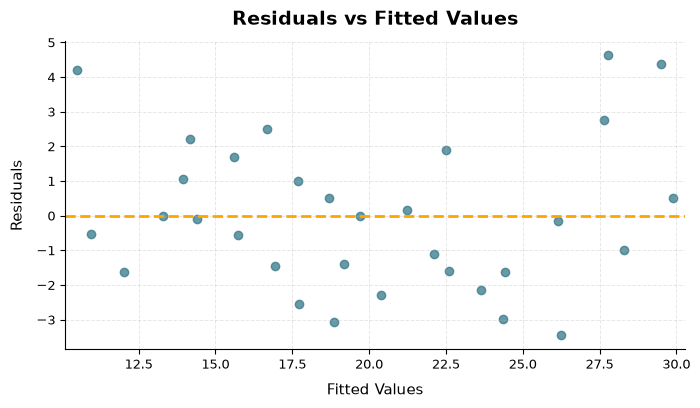

In [27]:
fig, ax = plt.subplots(figsize=(8, 4))

ax.scatter(
    predicted_values,
    residuals,
    color = "#347989",
    alpha = 0.75,
)

ax.axhline(
    y=0,
    ls = "--",
    color = "orange",
    linewidth=2
)

style_plot(
    ax,
    title="Residuals vs Fitted Values",
    xlabel="Fitted Values",
    ylabel="Residuals"
)

plt.show()

The points towards the right-hand side of the plot tend to be scattered slightly less densely suggesting the possibility of heteroscedasticity, where the variance of the residuals may vary systematically with the magnitude of the predicted values. However, it's essential to confirm the presence of heteroscedasticity using formal statistical tests or diagnostic procedures designed for this purpose.

An example of a statistical test is the **Breusch-Pagan test**. This test examines whether the variance of the residuals is dependent on the independent variables in the regression model. It is based on regressing the squared residuals on the independent variables, and the significance of the resulting test statistic indicates the presence of heteroscedasticity.

To implement the Breusch-Pagan test in Python, we can use the `het_breuschpagan` function from the `statsmodels.stats` module.

We will implement the Breusch-Pagan test as follows:
* Calculate the residuals from your fitted regression model.
* Perform the Breusch-Pagan test using the residuals and the independent variables.

In [19]:
# 1. Calculate residuals
residuals = ols.resid

# 2. Perform Breusch-Pagan test
bp_test_result = sms.het_breuschpagan(residuals, ols.model.exog)
print("Breusch-Pagan Test Results:")
print("LM Statistic:", bp_test_result[0])
print("LM-Test p-value:", bp_test_result[1])
print("F-Statistic:", bp_test_result[2])
print("F-Test p-value:", bp_test_result[3])

Breusch-Pagan Test Results:
LM Statistic: 14.91358896062286
LM-Test p-value: 0.13524415065662965
F-Statistic: 1.8329499825991353
F-Test p-value: 0.11634584353910254


---
### __Interpretation__
The **Breusch–Pagan test does not provide evidence of heteroscedasticity**.


The hypotheses are:

* **H₀:** The residuals have constant variance (**homoscedasticity**).
* **H₁:** The residual variance is not constant (**heteroscedasticity**).

Results:

| Test | Statistic | p-value |
| ---- | --------: | ------: |
| LM   |    14.914 |  0.1352 |
| F    |     1.833 |  0.1163 |


When interpreting the results of the **Breusch-Pagan test, we focus primarily on the p-values associated with the test statistics**.

Here's how we interpret the results:

- **LM-Test p-value**: This is the p-value associated with the Lagrange Multiplier (LM) test statistic. It tests the null hypothesis that there is no heteroscedasticity (i.e. the variance of the residuals is constant across all levels of the predictors). In our case, the `LM-Test p-value` is `0.135`, which is greater than the typical significance level of 0.05 (`LM p-value` = **0.1352 > 0.05**). Therefore, we fail to reject H₀, indicating that there is no strong evidence of heteroscedasticity in the residuals.

- **F-Test p-value**: This is the p-value associated with the F-statistic. It tests the same null hypothesis as the LM test but is based on a different statistic. In our case, the `F-Test p-value` is `0.116`, which is also greater than 0.05 (`F-test p-value` = **0.1163 > 0.05**). Similarly, we fail to reject the null hypothesis based on the F-Test, further supporting the conclusion that there is no strong evidence of heteroscedasticity. Therefore, **fail to reject H₀**.

Overall, based on these results, we can conclude that there is **no significant evidence of heteroscedasticity** in the residuals of the regression model which  implies that the assumption of homoscedasticity is likely satisfied. In other words, the variance of the residuals remains relatively constant across different levels of the predictor variables.

This is a desirable outcome because homoscedasticity is one of the key assumptions of linear regression analysis. When homoscedasticity is present, the **estimated coefficients are unbiased** and the **standard errors are reliable**, leading to **valid statistical inference**. Additionally, predictions and confidence intervals are more accurate and trustworthy when the assumption of homoscedasticity holds true.

### __Conclusion__

> **The Breusch–Pagan test indicates that there is no statistically significant evidence of heteroscedasticity in the OLS model. The constant-variance assumption appears reasonable.**

One important distinction: **failing to reject H₀ doesn't prove that the errors are perfectly homoscedastic**. It means the test did not find sufficient evidence of heteroscedasticity at the 5% level.

---
### __Checking for normality__
Here we attempt to confirm our assumption of normality amongst the residuals. If the residuals are non-normally distributed, confidence intervals can become too wide or too narrow, which leads to difficulty in estimating coefficients based on the minimisation of ordinary least squares.

We can check for violations of the normality assumption in two different ways:

- Plotting a histogram of the normalised residuals.
- Generating a Q-Q plot of the residuals.

### __Histogram of normalised residuals__

We create a histogram of the residuals to examine their distribution. It is fairly easy to recognise when a distribution resembles the classic **_bell curve_** shape of the normal distribution.

In [20]:
from statsmodels.graphics.gofplots import qqplot

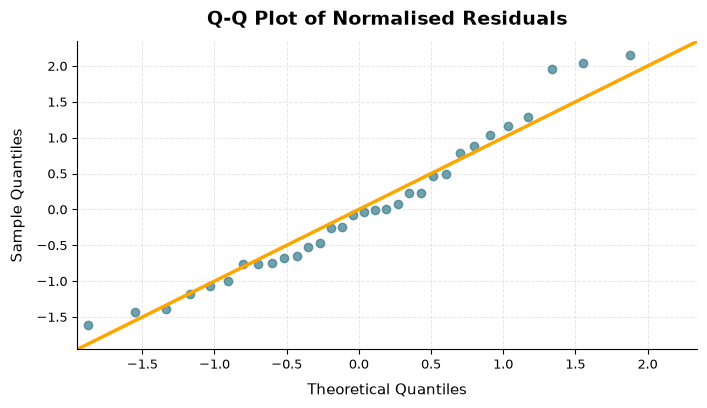

In [28]:
fig, ax = plt.subplots(figsize=(8, 4))

qqplot(
    ols.resid_pearson,
    line="45",
    fit=True,
    ax=ax
)

# Green Q-Q scatter points
ax.lines[0].set_color("#347989")
ax.lines[0].set_markerfacecolor("#347989")
ax.lines[0].set_markeredgecolor("#347989")

# Orange 45-degree reference line
ax.lines[1].set_color("orange")
ax.lines[1].set_linewidth(2.5)
ax.lines[0].set_alpha(0.7)

style_plot(
    ax,
    title="Q-Q Plot of Normalised Residuals",
    xlabel="Theoretical Quantiles",
    ylabel="Sample Quantiles"
)

plt.show()

Based on the two checks above, the residuals appear to be regularly distributed.

### __What you're checking__

The 45-degree line represents what we would expect if the residuals were approximately normally distributed.

- **Points close to the line** → residuals are approximately normal.
- **Small deviations at the ends** → usually not a major concern.
- **Strong curvature/S-shape** → possible non-normality.
- **Large deviations in the tails** → possible outliers or heavy-tailed residuals.

So, if your Q-Q plot has most points following the diagonal line, you can conclude:

> **The Q-Q plot indicates that the residuals are approximately normally distributed, as most observations lie close to the 45-degree reference line**

### **Checking for outliers in residuals**

The last check we'll make is for outliers amongst the residuals.

### **Plotting Cook's distance**

Cook's distance is a measure used in regression analysis to assess the influence of individual data points on the regression model. It quantifies how much the model's predictions change when a particular observation is removed from the dataset.

Observations with large Cook's distances have a disproportionate impact on the model, meaning that they significantly influence the estimated coefficients and overall fit of the regression model. These observations can potentially be influential outliers or leverage points that have a substantial effect on the regression results.

Therefore, it is common practice to examine observations with large Cook's distances more closely to determine if they are genuine outliers or influential points that need special consideration in the analysis.

In [22]:
from statsmodels.stats.outliers_influence import OLSInfluence as influence

#### __What Cook's distance tells you__

Cook's distance helps identify influential observations — individual data points that have a strong effect on the fitted OLS regression.

__A common rule of thumb is:__
``` python
threshold = 4 / len(c)
```

In [23]:
inf=influence(ols)
c, p = inf.cooks_distance

In [24]:
threshold = 4 / len(c)
print(f"Cook's distance threshold: {threshold:.4f}")

Cook's distance threshold: 0.1250


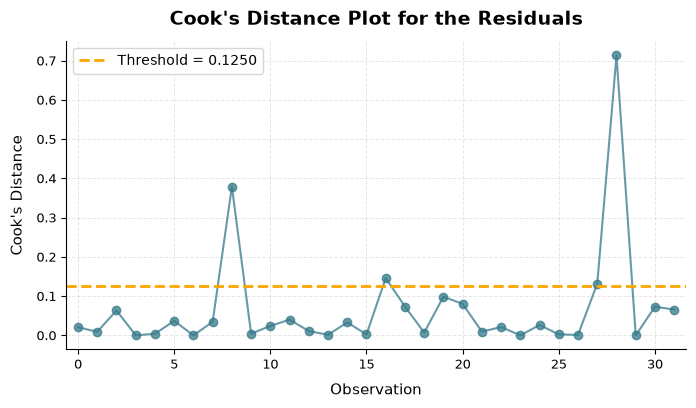

In [29]:
fig, ax = plt.subplots(figsize=(8, 4))

ax.plot(
    np.arange(len(c)),
    c,
    marker="o",
    color = "#347989",
    alpha = 0.75,
    linestyle="-"
)

threshold = 4 / len(c)

ax.axhline(
    threshold,
    linestyle="--",
    color = 'orange',
    linewidth=2,
    label=f"Threshold = {threshold:.4f}"
)

style_plot(
    ax,
    title="Cook's Distance Plot for the Residuals",
    xlabel="Observation",
    ylabel="Cook's Distance"
)

ax.legend()
plt.show()

__Interpretation:__ observations with Cook's distance substantially above the threshold deserve investigation. They are not automatically "bad" observations; they may simply have unusual combinations of predictor values or responses.

- It does appear that observations 8 and 28 are highly influential in this dataset, and may warrant closer examination.

### __Summary__

In this notebook, we embarked on a journey to evaluate the quality of a regression model through a thorough analysis of its residuals. We meticulously examined four key statistical phenomena: **independence**, **homoscedasticity**, **normality**, and **outliers**. Employing visualisations such as **scatter plots** of residuals against predictor variables, **histograms**, and **Q-Q plots**, we scrutinised the adherence of the residuals to these fundamental assumptions. Additionally, we utilised **Cook's distance** to pinpoint influential outliers in the dataset. By the end of this exploration, we gained insights into **interpreting residuals**, **identifying patterns**, and **diagnosing potential issues** in regression models. Armed with this knowledge, we've equipped ourselves with a robust set of tools to ensure the reliability and accuracy of our regression analyses.

---
#### __Quiz__

__Question 1:__
> During an advanced regression analysis workflow, why would a data scientist calculate Cook's distance for every observation in their dataset, and how does this metric guide model refinement?

__Answer__
> To identify highly influential data points or outliers that exert an outsized impact on the regression coefficients, allowing the analyst to inspect them for errors or anomalous behavior.

__Question 2:__
> A machine learning engineer evaluates two different multi-variable models using scikit-learn to predict housing prices. They calculate the performance metrics for both models on a test dataset and record the results in the table below:

Metric | Model A | Model B
|:-----:|:------:|:------:|
|Mean Absolute Error (MAE) | 12,000 | 18,000
|Root Mean Squared Error (RMSE) | 15,000 | 32,000

> Based on these accuracy metrics, which model performed better, and what does the large difference between MAE and RMSE in Model B indicate?

__Answer:__
> Model A performed better because both its MAE and RMSE are lower; the large gap in Model B indicates that Model B's predictions suffered from a few very large errors or outliers.

__Question 3:__

> While evaluating a Multiple Linear Regression model using the statsmodels summary output, a data scientist notices that two predictor variables-"Years of Education" and "Current Salary"-have a Variance Inflation Factor (VIF) value of 14.5. What does this specific diagnostic signal indicate about the model?

__Answer__
> The model suffers from severe multicollinearity, meaning these two predictors are highly correlated with each other, which destabilizes the model's coefficients and standard errors.

__Question 4:__

> To assess whether a Multiple Linear Regression model satisfies its core statistical assumptions, a developer generates a diagnostic plot graphing the residuals on the vertical axis against the model's fitted (predicted) values on the horizontal axis. If the resulting plot shows a distinct, widening "fan" shape rather than a random cloud of points, which assumption is violated, and what does it mean?

__Answer:__

> Homoscedasticity; it means the model suffers from heteroscedasticity, where the variance of the errors is not constant across different levels of predicted values.

__Question:__

> Multiple Linear Regression (MLR) extends Simple Linear Regression by incorporating more than one predictor variable. Which of the following equations correctly represents the structural form of an MLR model with two predictors ($x_1$ and $x_2$), and how should a single coefficient (such as $b_1$) be interpreted?

__Answer:__

> $y = b_0 + b_1x_1 + b_2x_2$ -- The coefficient b1 represents the expected change in the dependent variable $y$ for every one-unit increase in $x_1$, holding $x_2$ constant.